<a href="https://colab.research.google.com/github/Anshitha9286/ASSIGNMENT/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Car Price Prediction using Machine Learning

This project aims to predict car prices using different machine learning regression algorithms.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.model_selection import GridSearchCV

Import Libraries

The required libraries are imported to load the dataset, preprocess the data, build machine learning models, and evaluate their performance.

In [6]:
from google.colab import files
uploaded=files.upload()

Saving CarPrice_Assignment.csv to CarPrice_Assignment (1).csv


Load the Dataset

The dataset is loaded using Pandas. It contains different features of cars along with their prices.

In [7]:
df = pd.read_csv("CarPrice_Assignment.csv")

In [8]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [9]:
df.shape

(205, 26)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

Data Exploration

The dataset is explored using head(), shape(), info(), and describe() to understand the data, data types, and summary statistics.

In [11]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [12]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [13]:
df.duplicated().sum()

np.int64(0)

Data Preprocessing

The dataset is cleaned by checking for missing values and duplicate records. Categorical columns are converted into numerical values using Label Encoding.

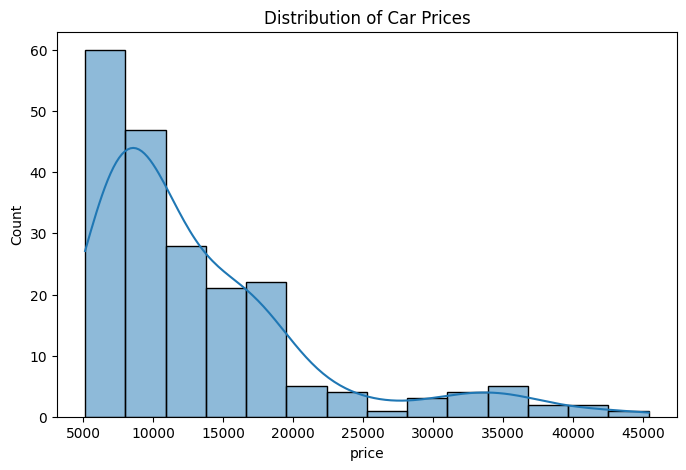

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

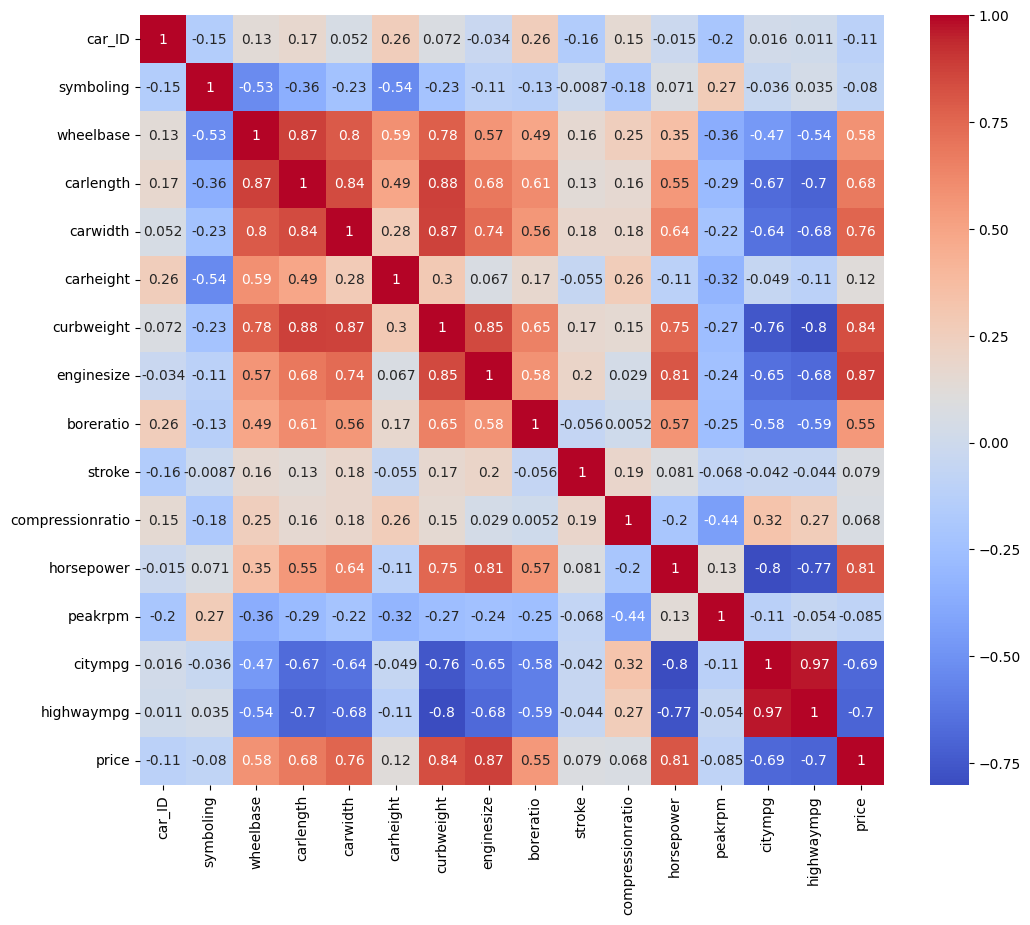

In [15]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [16]:
label_encoder = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = label_encoder.fit_transform(df[column])

Feature Selection

The target variable is price, and all the remaining columns are used as input features for prediction

In [17]:
X = df.drop("price", axis=1)
y = df["price"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train-Test Split

The dataset is divided into training data (80%) and testing data (20%). The model is trained using the training data and evaluated using the testing data.

In [33]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

Linear Regression

Linear Regression is used to predict car prices by finding the relationship between the input features and the target variable.

In [32]:
lr_r2 = r2_score(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

In [31]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

Decision Tree Regressor

Decision Tree Regressor predicts the price by splitting the data into different branches based on feature values.

In [30]:
dt_r2 = r2_score(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)

In [29]:
rf = RandomForestRegressor(
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

Random Forest Regressor

Random Forest Regressor combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [28]:
rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

In [27]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

Gradient Boosting Regressor

Gradient Boosting Regressor builds several trees one after another and improves the prediction by correcting previous errors.

In [26]:
svr = SVR()
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)

Support Vector Regressor (SVR)

Support Vector Regressor predicts car prices by finding the best fit within a specified error margin

In [34]:
results = pd.DataFrame({
'Model':['Linear Regression',
         'Decision Tree',
         'Random Forest',
         'Gradient Boosting',
         'SVR'],

'R2 Score':[
r2_score(y_test,lr_pred),
r2_score(y_test,dt_pred),
r2_score(y_test,rf_pred),
r2_score(y_test,gb_pred),
r2_score(y_test,svr_pred)
],

'MSE':[
mean_squared_error(y_test,lr_pred),
mean_squared_error(y_test,dt_pred),
mean_squared_error(y_test,rf_pred),
mean_squared_error(y_test,gb_pred),
mean_squared_error(y_test,svr_pred)
],

'MAE':[
mean_absolute_error(y_test,lr_pred),
mean_absolute_error(y_test,dt_pred),
mean_absolute_error(y_test,rf_pred),
mean_absolute_error(y_test,gb_pred),
mean_absolute_error(y_test,svr_pred)
]
})
results

,Model,R2 Score,MSE,MAE
0,Linear Regression,0.844116,1.230612e+07,2087.306212
1,Decision Tree,0.879253,9.532216e+06,2090.699195
2,Random Forest,0.957176,3.380660e+06,1303.813122
3,Gradient Boosting,0.932387,5.337674e+06,1602.778175
4,SVR,-0.101955,8.699279e+07,5707.040766


Model Evaluation

All models are compared using R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE). The model with the highest R² score and the lowest error values is considered the best.

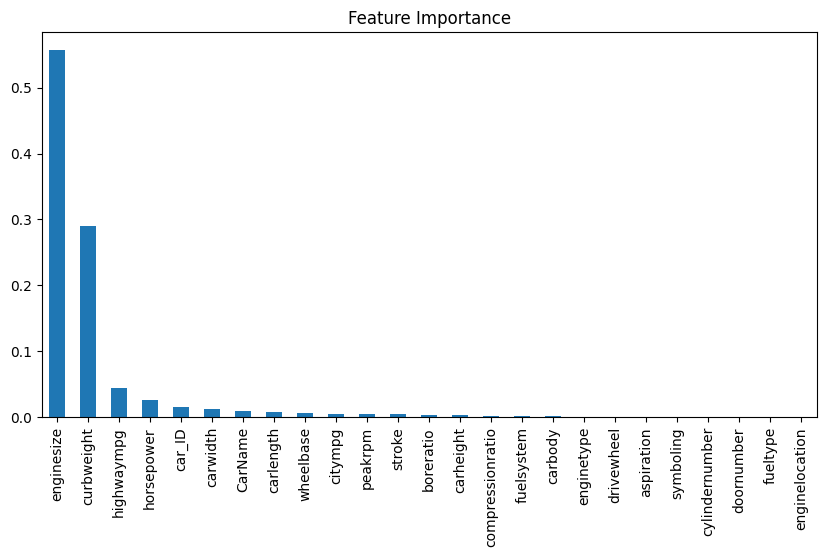

In [35]:
importance = pd.Series(
rf.feature_importances_,
index=X.columns
)
importance.sort_values(
ascending=False
).plot(
kind='bar',
figsize=(10,5)
)
plt.title("Feature Importance")
plt.show()

Feature Importance

Feature importance helps identify which variables have the greatest impact on predicting car prices

In [36]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)
print("Best Parameters:", grid.best_params_)
print("R² Score:", r2_score(y_test, best_pred))

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}
R² Score: 0.9579441656339228


Hyperparameter Tuning

Hyperparameter tuning is performed using GridSearchCV to find the best parameter values for the Random Forest model and improve its performance

Conclusion

Five regression models were used to predict car prices. After comparing their performance, the Random Forest Regressor gave the best results. Hyperparameter tuning further improved the model.

Best Parameters:

max_depth = 15
min_samples_split = 2
n_estimators = 300

The tuned model achieved an R² Score of 0.9579, which means it can explain about 95.79% of the variation in car prices. Therefore, the Random Forest Regressor is the best model for this dataset.